In [5]:
!pip install --upgrade pip
!pip install numpy pandas matplotlib scikit-learn opencv-python pillow tqdm
!pip install tensorflow==2.14.0 # choose TF version compatible with your system
!pip install transformers sentencepiece # for pretrained NLP inference
!pip install streamlit # for final UI (optional)
!pip install mediapipe

  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\adity\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/51.0 MB ? eta -:--:--
    --------------------------------------- 0.8/51.0 MB 3.0 MB/s eta 0:00:17
   - -------------------------------------- 1.6/51.0 MB 4.0 MB/s eta 0:00:13
   -- ------------------------------------- 2.6/51.0 MB 4.0 MB/s eta 0:00:13
   --- ------------------------------------ 4.2/51.0 MB 4.8 MB/s eta 0:00:10
   ---- ----------------------------------- 5.5/51.0 MB 5.3 MB/s eta 0:00:09
   ----- ---------------------------------- 6.8/51.0 MB 5.3 MB/s eta 0:00:09
   ------ --------------------------------- 7.9/51.0 MB 5.2 MB/s eta 0:00:09
   ------ --------------------------------- 8.7/51.0 MB 5.3 MB/s eta 0:00:08
   -------- ----

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\adity\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Dataset extracted!
Found 24176 images belonging to 5 classes.
Found 6043 images belonging to 5 classes.
✅ Remaining Classes: {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3, 'surprise': 4}


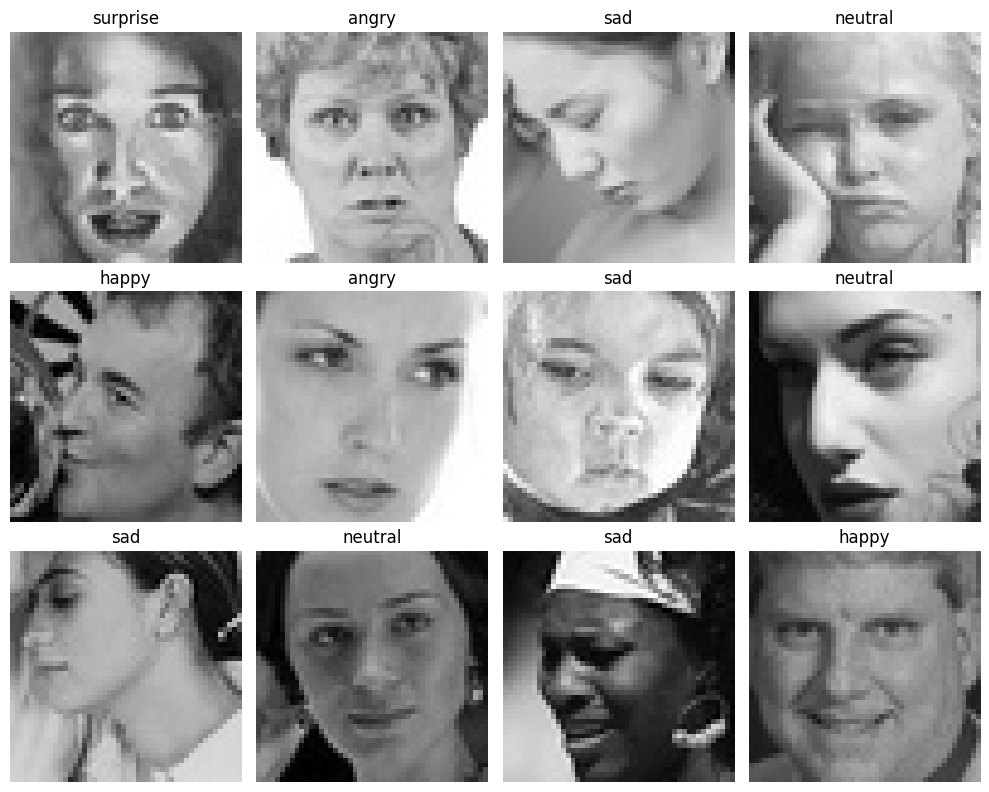

In [1]:
# ===============================
# Milestone 1: Dataset Preparation (Updated)
# ===============================
import os, shutil, zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Paths
zip_path = "C:\\Users\\adity\\Downloads\\archive (3).zip"
extract_path = "/mnt/data/dataset"

# ✅ Extract dataset
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("✅ Dataset extracted!")

# Paths for train/test
train_path = os.path.join(extract_path, "train")
val_path   = os.path.join(extract_path, "test")

# ✅ Remove unwanted emotion folders
remove_classes = ["fear", "disgust"]

for split_path in [train_path, val_path]:
    for cls in remove_classes:
        cls_path = os.path.join(split_path, cls)
        if os.path.exists(cls_path):
            shutil.rmtree(cls_path)
            print(f"🗑️ Removed folder: {cls_path}")

# ===============================
# Data Generators
# ===============================
img_size = 48
batch_size = 32

datagen = ImageDataGenerator(rescale=1./255)
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

val_generator = datagen.flow_from_directory(
    val_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

print("✅ Remaining Classes:", train_generator.class_indices)

# ===============================
# Show Sample Images
# ===============================
x_batch, y_batch = next(train_generator)

plt.figure(figsize=(10, 8))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(x_batch[i])
    plt.title(list(train_generator.class_indices.keys())[np.argmax(y_batch[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,165 (1.36 MB)

 Trainable params: 356,165 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.3628 - loss: 1.4666 - val_accuracy: 0.4802 - val_loss: 1.2687
Epoch 2/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.4896 - loss: 1.2490 - val_accuracy: 0.5335 - val_loss: 1.1471
Epoch 3/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.5410 - loss: 1.1318 - val_accuracy: 0.5643 - val_loss: 1.0713
Epoch 4/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.5804 - loss: 1.0573 - val_accuracy: 0.5931 - val_loss: 1.0346
Epoch 5/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6049 - loss: 1.0004 - val_accuracy: 0.6111 - val_loss: 0.9685
Epoch 6/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.6257 - loss: 0.9530 - val_accuracy: 0.6128 - val_loss: 0.9657
Epoch 7/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 83s 109ms/step - accuracy: 0.6445 - loss: 0.9145 - val_accuracy: 0.6313 - val_loss: 0.9441
Epoch 8/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.6611 - loss: 0.8765 -

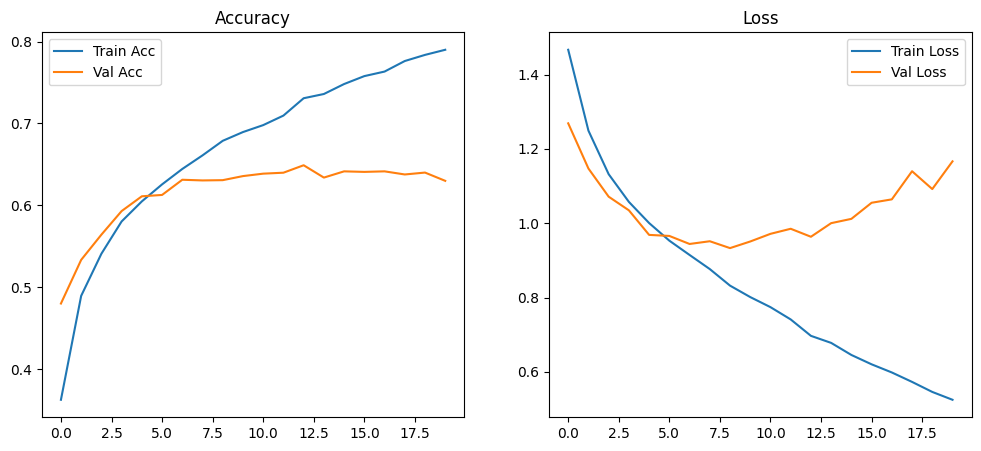

In [4]:

# Milestone 2: CNN Model

num_classes = len(train_generator.class_indices)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ===============================
# Milestone 3: Training
# ===============================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)


# Accuracy & Loss

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()
model.save("emotion_model.h5")


189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6300 - loss: 1.1664

📈 Test Loss: 1.1663883924484253
✅ Test Accuracy: 0.6299850940704346
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step

🧩 Confusion Matrix:
 [[169 262 194 220 113]
 [279 469 373 437 216]
 [185 344 257 289 158]
 [181 361 278 278 149]
 [120 258 185 162 106]]


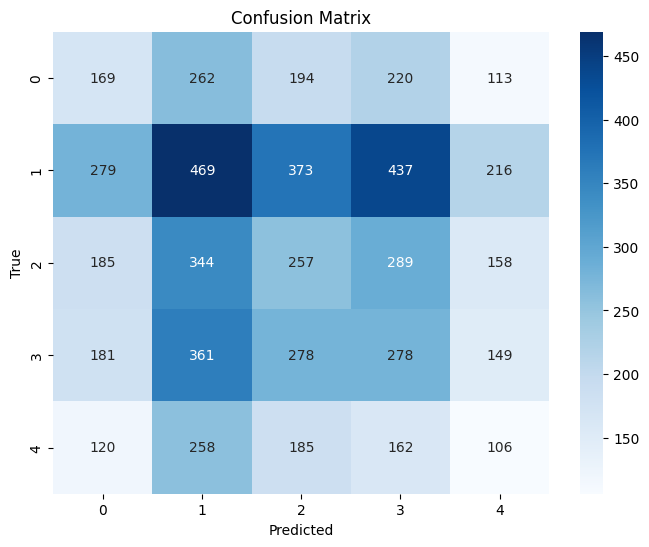


📋 Classification Report:
               precision    recall  f1-score   support

       angry       0.18      0.18      0.18       958
       happy       0.28      0.26      0.27      1774
     neutral       0.20      0.21      0.20      1233
         sad       0.20      0.22      0.21      1247
    surprise       0.14      0.13      0.13       831

    accuracy                           0.21      6043
   macro avg       0.20      0.20      0.20      6043
weighted avg       0.21      0.21      0.21      6043



In [11]:
# ===============================
# 📊 Model Evaluation with Score & Confusion Matrix (for generators)
# ===============================
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Evaluate model on generator
score = model.evaluate(val_generator, verbose=1)
print("\n📈 Test Loss:", score[0])
print("✅ Test Accuracy:", score[1])

# ✅ Get predictions from generator
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes  # true labels from generator

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("\n🧩 Confusion Matrix:\n", cm)

# ✅ Plot Confusion Matrix (optional)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# ✅ Classification Report
target_names = list(val_generator.class_indices.keys())
print("\n📋 Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=target_names))


In [1]:
import pandas as pd

music_df = pd.read_csv("C:\\Users\\adity\\Downloads\\archive (4)\\Music Info.csv")
music_df.head()


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.000000,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.000000,0.2070,0.651,174.426,4
2,TROUVHL128F426C441,Come as You Are,Nirvana,https://p.scdn.co/mp3-preview/a1c11bb1cb231031...,0keNu0t0tqsWtExGM3nT1D,"rock, alternative, alternative_rock, 90s, grunge",RnB,1991,218920,0.508,...,4,-5.783,0,0.0400,0.000175,0.000459,0.0878,0.543,120.012,4
3,TRUEIND128F93038C4,Take Me Out,Franz Ferdinand,https://p.scdn.co/mp3-preview/399c401370438be4...,0ancVQ9wEcHVd0RrGICTE4,"rock, alternative, indie, alternative_rock, in...",NaN,2004,237026,0.279,...,9,-8.851,1,0.0371,0.000389,0.000655,0.1330,0.490,104.560,4
4,TRLNZBD128F935E4D8,Creep,Radiohead,https://p.scdn.co/mp3-preview/e7eb60e9466bc3a2...,01QoK9DA7VTeTSE3MNzp4I,"rock, alternative, indie, alternative_rock, in...",RnB,2008,238640,0.515,...,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841,4


In [ ]:

import numpy as np

# Load dataset
#music_df = pd.read_csv("Music Info.csv")

def recommend_songs(emotion, n=5):
    if emotion == "sad":
        recs = music_df[(music_df['valence'] > 0.6) & (music_df['energy'] > 0.5)]
    elif emotion == "happy":
        recs = music_df[music_df['valence'] > 0.5]
    elif emotion == "angry":
        recs = music_df[(music_df['valence'] < 0.4) & (music_df['energy'] < 0.5)]
    elif emotion == "fear":
        recs = music_df[(music_df['valence'].between(0.4, 0.6)) & (music_df['energy'] < 0.6)]
    else:  # neutral or unknown
        recs = music_df.sample(n)
    
    if recs.empty:
        recs = music_df.sample(n)  # fallback
    
    return recs.sample(min(n, len(recs)))[['name','artist','spotify_preview_url','valence','energy']]

# Example usage:
emotion = "sad"  
print("Detected emotion:", emotion)
print(recommend_songs(emotion, n=5))


Detected emotion: sad
                    name              artist  \
31339    You Don't Wanna              Tricky   
13303  Conspiracy of One       The Offspring   
38899         The Planet          Gang Starr   
17239              Kelly             Van She   
1619         Stacy's Mom  Fountains of Wayne   

                                     spotify_preview_url  valence  energy  
31339  https://p.scdn.co/mp3-preview/a6510ac96c5b523a...    0.782   0.839  
13303  https://p.scdn.co/mp3-preview/85d1b6588a27f6d6...    0.748   0.959  
38899  https://p.scdn.co/mp3-preview/e75593a09fc5cecd...    0.607   0.725  
17239  https://p.scdn.co/mp3-preview/576f722b5b704fcc...    0.602   0.785  
1619   https://p.scdn.co/mp3-preview/20943ef75faadd4c...    0.915   0.729  


In [9]:
!pip install mediapipe

  Using cached mediapipe-0.10.21-cp312-cp312-win_amd64.whl.metadata (10 kB)
  Using cached jax-0.7.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.7.2-cp312-cp312-win_amd64.whl.metadata (1.4 kB)
  Using cached opencv_contrib_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (20 kB)
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
  Using cached jax-0.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.7.1-cp312-cp312-win_amd64.whl.metadata (1.3 kB)
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
  Using cached opencv_contrib_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached mediapipe-0.10.21-cp312-cp312-win_amd64.whl (51.0 MB)
Using cached jax-0.7.1-py3-none-any.whl (2.8 MB)
Using cached jaxlib-0.7.1-cp312-cp312-win_amd64.whl (61.2 MB)
Using cach

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\adity\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt
import os
import mediapipe as mp # Import MediaPipe

# --- 1. Define Paths and Labels ---

# IMPORTANT: REPLACE THIS WITH YOUR ACTUAL MODEL FILE PATH
EMOTION_MODEL_PATH = 'C:\\path\\to\\your\\fer_tl.h5' 

# The 7 emotion classes from your model
EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


# --- 2. Load Keras Model ---

try:
    if not os.path.exists(EMOTION_MODEL_PATH):
        raise FileNotFoundError(f"Keras model not found at: {EMOTION_MODEL_PATH}")
    emotion_model = tf.keras.models.load_model(EMOTION_MODEL_PATH)
    print("✅ Emotion model loaded successfully.")

except Exception as e:
    print(f"❌ Initialization Error: {e}")
    emotion_model = None


# --- 3. Core Inference Function with MediaPipe ---

def check_model_prediction_mediapipe(image_path):
    """
    Detects faces using MediaPipe, predicts emotion using Keras, 
    and draws bounding boxes.
    """
    if emotion_model is None:
        print("\nCannot run prediction: Emotion model failed to load. Please fix the file path in Step 1.")
        return

    print(f"\nAnalyzing image: {image_path}")
    
    # Load image (MediaPipe and Matplotlib work best with RGB)
    frame = cv2.imread(image_path)
    if frame is None:
        print(f"Error: Could not open or find the image at '{image_path}'")
        return
    
    # Convert BGR (OpenCV default) to RGB for MediaPipe
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Get image dimensions for normalization
    H, W, _ = frame.shape
    
    # Initialize MediaPipe Face Detection
    mp_face_detection = mp.solutions.face_detection
    
    with mp_face_detection.FaceDetection(
        model_selection=1, # 0 for short-range (fast), 1 for full-range (accurate)
        min_detection_confidence=0.5
    ) as face_detection:
        
        # Process the image
        results = face_detection.process(rgb_frame)
        
        detected_faces = 0
        
        if results.detections:
            for detection in results.detections:
                detected_faces += 1
                
                # Extract normalized bounding box coordinates
                bboxC = detection.location_data.relative_bounding_box
                
                # Convert normalized coordinates to pixel values (x, y, w, h)
                x = int(bboxC.xmin * W)
                y = int(bboxC.ymin * H)
                w = int(bboxC.width * W)
                h = int(bboxC.height * H)

                # Ensure box is within frame boundaries
                x = max(0, x)
                y = max(0, y)
                x_end = min(W, x + w)
                y_end = min(H, y + h)
                w = x_end - x
                h = y_end - y
                
                # Convert the face ROI to grayscale for your FER model input
                roi_gray = cv2.cvtColor(frame[y:y + h, x:x + w], cv2.COLOR_BGR2GRAY)
                roi_gray = cv2.resize(roi_gray, (48, 48), interpolation=cv2.INTER_AREA)

                if np.sum([roi_gray]) != 0:
                    # Preprocess the ROI for the Keras model
                    roi = roi_gray.astype('float') / 255.0
                    roi = img_to_array(roi)
                    roi = np.expand_dims(roi, axis=0)
                    roi = np.expand_dims(roi, axis=3)

                    # Make a prediction
                    prediction = emotion_model.predict(roi, verbose=0)[0]
                    emotion_index = prediction.argmax()
                    emotion = EMOTION_LABELS[emotion_index]
                    confidence = prediction[emotion_index] * 100 

                    # **1. Draw Bounding Box** (Color: Cyan, Thickness: 2)
                    cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 255, 0), 2)
                    
                    # **2. Annotation for Accuracy Check**
                    label = f"{emotion}: {confidence:.2f}%"
                    cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

                    print(f"   -> Predicted Emotion: {emotion} | Confidence (Accuracy): {confidence:.2f}%")
                else:
                    cv2.putText(frame, 'No Face Data', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
                    print("   -> Face detected, but image region was empty/corrupted.")

        print(f"Detected {detected_faces} face(s).")


    # --- Output Result ---
    # Convert back to RGB for Matplotlib display
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Display the image with bounding box
    plt.figure(figsize=(8, 8))
    plt.imshow(img_rgb)
    plt.title("Model Prediction with Bounding Box")
    plt.axis('off')
    plt.show()

# --- Example Usage ---

# Replace with your actual image path
check_model_prediction_mediapipe("C:\\Users\\adity\\Downloads\\archive (3)\\test\\happy\\PublicTest_9659355.jpg")

ModuleNotFoundError: No module named 'mediapipe'